# Modèle ML d'affluence — HackatonMobilité

Ce notebook présente la brique IA du projet : la **prédiction du niveau d'affluence** dans les stations de transport francilien.

## Contexte

L'API IDFM (Île-de-France Mobilités) retourne des itinéraires mais **n'indique pas si la rame va être bondée**. Notre système enrichit chaque itinéraire avec un score de confort, dont la dimension affluence est au cœur.

### Architecture de la solution

```
Station connue (761 stations IDFM 2023)
    → Lookup données réelles       [source = "reel"]
    → score = f(% validations/heure)

Station inconnue (Transilien, Grand Paris Express…)
    → RandomForestRegressor        [source = "ml"]
    → score = f(heure, jour, poids_station)
```

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR  = Path("../data")
MODEL_DIR = Path("../models")

plt.rcParams["figure.figsize"]     = (12, 4)
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False
print("Imports OK")

Imports OK


---
## 1. Exploration des données réelles (IDFM 2023)

In [2]:
with open(DATA_DIR / "affluence_horaire.json", encoding="utf-8") as f:
    idx = json.load(f)

stations = idx["stations"]
p97      = idx["p97_pct"]

print(f"Source      : {idx['source']}")
print(f"Nb stations : {len(stations)}")
print(f"p97         : {p97}%  (au-delà = station très chargée)")
print()
print("Types de jours :")
for k, v in idx["cat_jour"].items():
    print(f"  {k:<8} = {v}")

Source      : IDFM histo-validations-reseau-ferre 2023 (S1+S2)
Nb stations : 761
p97         : 12.505%  (au-delà = station très chargée)

Types de jours :
  JOHV     = Jours ouvrables hors vacances scolaires (lun-ven)
  JOVS     = Jours ouvrables vacances scolaires (lun-ven)
  SAHV     = Samedis hors vacances
  SAVS     = Samedis vacances scolaires
  DIJFP    = Dimanches, jours fériés et ponts


In [3]:
# Aperçu : profil horaire de Châtelet un lundi (JOHV)
chatelet = stations["CHATELET"]["JOHV"]
heures   = list(range(24))
pcts     = [chatelet.get(str(h), 0) for h in heures]

df_apercu = pd.DataFrame({"heure": heures, "% validations": pcts})
print(df_apercu.to_string(index=False))

 heure  % validations
     0         2.2925
     1         0.4850
     2         0.0625
     3         0.0250
     4         0.0325
     5         0.5150
     6         0.5950
     7         1.6250
     8         3.3625
     9         2.7000
    10         2.0825
    11         2.7225
    12         3.8425
    13         4.6550
    14         4.8675
    15         5.9975
    16         7.9875
    17        11.3550
    18        12.9450
    19        10.6700
    20         6.9275
    21         5.2125
    22         4.8875
    23         4.1375


---
## 2. Visualisation des profils horaires

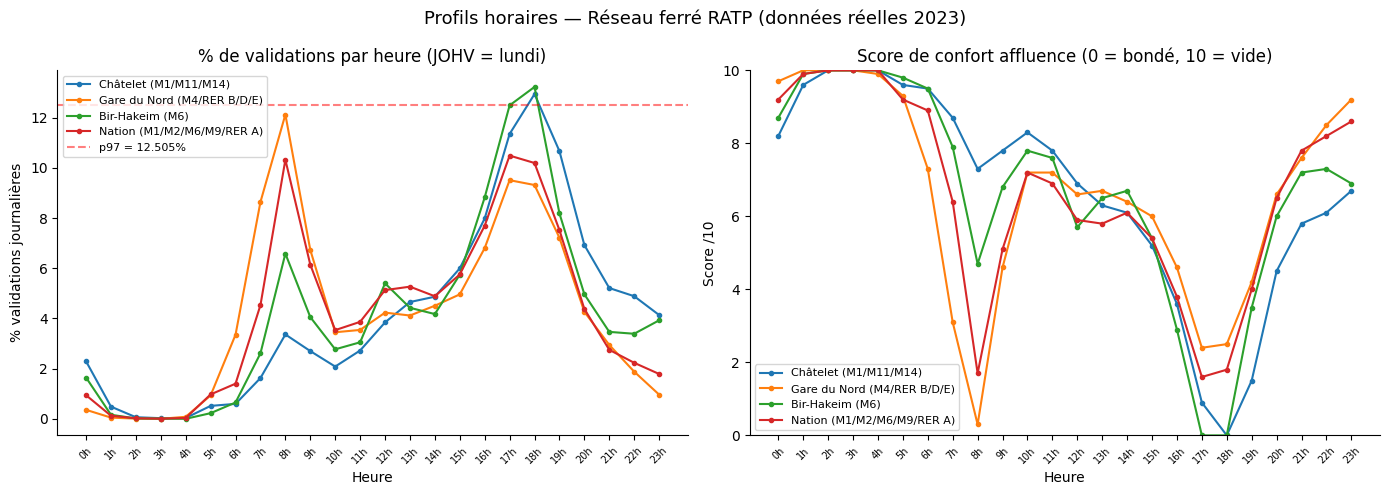

In [4]:
def get_profil(station_key, cat="JOHV"):
    profil = stations.get(station_key, {}).get(cat, {})
    return [profil.get(str(h), 0) for h in range(24)]

def pct_to_score(pcts):
    return [round(max(0.0, 10.0 * (1 - p / p97)), 1) for p in pcts]

stations_a_comparer = {
    "CHATELET":     "Châtelet (M1/M11/M14)",
    "GARE DU NORD": "Gare du Nord (M4/RER B/D/E)",
    "BIR HAKEIM":   "Bir-Hakeim (M6)",
    "NATION":       "Nation (M1/M2/M6/M9/RER A)",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
heures = list(range(24))

for key, label in stations_a_comparer.items():
    pcts = get_profil(key)
    axes[0].plot(heures, pcts, marker="o", markersize=3, label=label)
    axes[1].plot(heures, pct_to_score(pcts), marker="o", markersize=3, label=label)

axes[0].axhline(p97, color="red", linestyle="--", alpha=0.5, label=f"p97 = {p97}%")
axes[0].set_title("% de validations par heure (JOHV = lundi)")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("% validations journalières")
axes[0].legend(fontsize=8)

axes[1].set_title("Score de confort affluence (0 = bondé, 10 = vide)")
axes[1].set_xlabel("Heure")
axes[1].set_ylabel("Score /10")
axes[1].set_ylim(0, 10)
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xticks(heures)
    ax.set_xticklabels([f"{h}h" for h in heures], rotation=45, fontsize=7)

plt.suptitle("Profils horaires — Réseau ferré RATP (données réelles 2023)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Semaine vs week-end

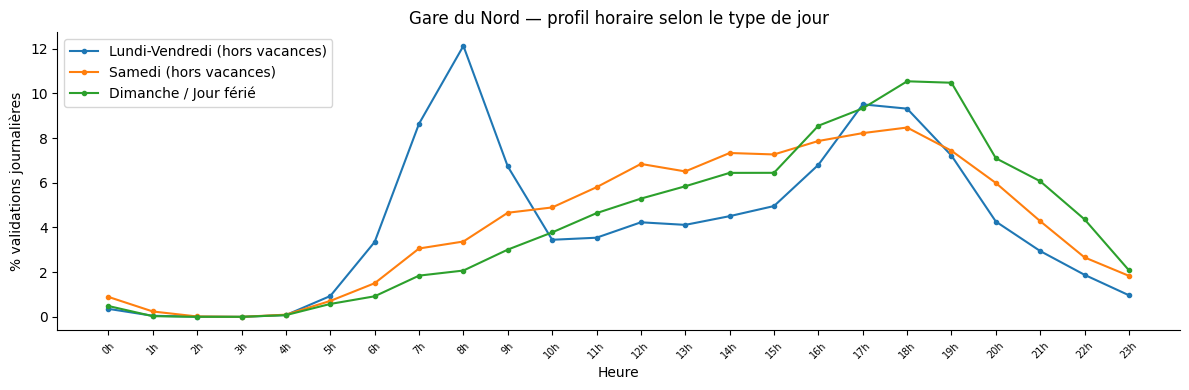

Gare du Nord à 8h : 12.1% (lundi) vs 2.1% (dimanche)
→ 5.9× plus chargée en semaine


In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

cat_labels = {
    "JOHV":  "Lundi-Vendredi (hors vacances)",
    "SAHV":  "Samedi (hors vacances)",
    "DIJFP": "Dimanche / Jour férié",
}

for cat, label in cat_labels.items():
    pcts = get_profil("GARE DU NORD", cat)
    ax.plot(heures, pcts, marker="o", markersize=3, label=label)

ax.set_title("Gare du Nord — profil horaire selon le type de jour")
ax.set_xlabel("Heure")
ax.set_ylabel("% validations journalières")
ax.set_xticks(heures)
ax.set_xticklabels([f"{h}h" for h in heures], rotation=45, fontsize=7)
ax.legend()
plt.tight_layout()
plt.show()

pct_lun  = stations["GARE DU NORD"]["JOHV"].get("8", 0)
pct_dim  = stations["GARE DU NORD"].get("DIJFP", {}).get("8", 0)
print(f"Gare du Nord à 8h : {pct_lun:.1f}% (lundi) vs {pct_dim:.1f}% (dimanche)")
print(f"→ {pct_lun/pct_dim:.1f}× plus chargée en semaine")

---
## 4. Entraînement du RandomForest (fallback stations inconnues)

Pour les stations absentes de l'index (Transilien, Grand Paris Express…), un modèle ML prédit le score à partir de l'**heure** et du **jour de la semaine**.

In [6]:
rows = []
for station_key, profil_station in stations.items():
    for cat, profil_cat in profil_station.items():
        jour = {"JOHV": 0, "JOVS": 2, "SAHV": 5, "SAVS": 5, "DIJFP": 6}.get(cat, 0)
        is_weekend = 1 if jour >= 5 else 0
        for h_str, pct in profil_cat.items():
            score = max(0.0, 10.0 * (1 - pct / p97))
            rows.append({
                "heure":        int(h_str),
                "jour_semaine": jour,
                "is_weekend":   is_weekend,
                "score":        round(score, 2),
            })

df = pd.DataFrame(rows)
print(f"Dataset d'entraînement : {len(df):,} lignes")
print(df.describe().round(2))

Dataset d'entraînement : 84,760 lignes
          heure  jour_semaine  is_weekend     score
count  84760.00      84760.00    84760.00  84760.00
mean      12.09          3.57        0.59      6.54
std        6.67          2.26        0.49      2.68
min        0.00          0.00        0.00      0.00
25%        7.00          2.00        0.00      4.50
50%       12.00          5.00        1.00      6.76
75%       18.00          5.00        1.00      9.02
max       23.00          6.00        1.00     10.00


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error

FEATURES = ["heure", "jour_semaine", "is_weekend"]
X = df[FEATURES].values
y = df["score"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
model.fit(X_train, y_train)

mae    = mean_absolute_error(y_test, model.predict(X_test))
mae_cv = -cross_val_score(model, X, y, cv=5, scoring="neg_mean_absolute_error").mean()

print(f"MAE test          : {mae:.3f} / 10")
print(f"MAE cross-val (5) : {mae_cv:.3f} / 10")
print()
print("Importance des features :")
for feat, imp in zip(FEATURES, model.feature_importances_):
    bar = "█" * int(imp * 40)
    print(f"  {feat:<15} {imp:.3f}  {bar}")

MAE test          : 1.022 / 10
MAE cross-val (5) : 1.119 / 10

Importance des features :
  heure           0.866  ██████████████████████████████████
  jour_semaine    0.087  ███
  is_weekend      0.047  █


---
## 5. Prédictions ML vs données réelles

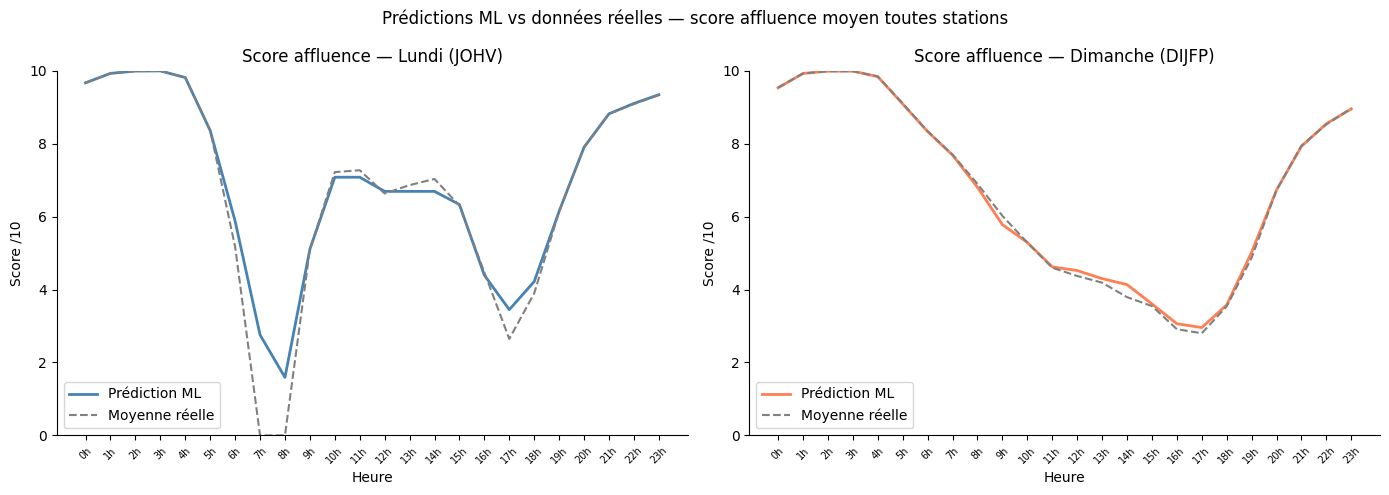

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (jour, cat, label, color) in zip(axes, [
    (0, "JOHV",  "Lundi (JOHV)",    "steelblue"),
    (6, "DIJFP", "Dimanche (DIJFP)", "coral"),
]):
    is_we  = 1 if jour >= 5 else 0
    preds  = model.predict([[h, jour, is_we] for h in heures])

    # Moyenne réelle sur toutes les stations pour ce type de jour
    reels = []
    for h in heures:
        vals = [s.get(cat, {}).get(str(h)) for s in stations.values()]
        vals = [v for v in vals if v is not None]
        reels.append(max(0.0, 10.0 * (1 - np.mean(vals) / p97)) if vals else 5.0)

    ax.plot(heures, preds, label="Prédiction ML",  color=color,  linewidth=2)
    ax.plot(heures, reels, label="Moyenne réelle", color="gray", linestyle="--", linewidth=1.5)
    ax.set_title(f"Score affluence — {label}")
    ax.set_xlabel("Heure")
    ax.set_ylabel("Score /10")
    ax.set_ylim(0, 10)
    ax.set_xticks(heures)
    ax.set_xticklabels([f"{h}h" for h in heures], rotation=45, fontsize=7)
    ax.legend()

plt.suptitle("Prédictions ML vs données réelles — score affluence moyen toutes stations", fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Démonstration — score sur des cas concrets

In [9]:
import unicodedata, re

def norm_station(name):
    name = name.upper().strip()
    name = unicodedata.normalize("NFD", name)
    name = "".join(c for c in name if unicodedata.category(c) != "Mn")
    name = re.sub(r"[^A-Z0-9 ]", " ", name)
    return re.sub(r"\s+", " ", name).strip()

ALIASES = {
    "CHATELET LES HALLES":     "CHATELET",
    "MONTPARNASSE BIENVENUE":  "MONTPARNASSE",
    "CHARLES DE GAULLE ETOILE": "CH D G ETOILE",
}

DOW_TO_CAT = {0:"JOHV",1:"JOHV",2:"JOHV",3:"JOHV",4:"JOHV",5:"SAHV",6:"DIJFP"}

def score_reel(station_name, heure, jour_semaine):
    key = norm_station(station_name)
    key = ALIASES.get(key, key)
    cat = DOW_TO_CAT.get(jour_semaine, "JOHV")
    profil = stations.get(key, {}).get(cat) or stations.get(key, {}).get("JOHV", {})
    pct    = profil.get(str(heure))
    if pct is None:
        return None
    return round(max(0.0, 10.0 * (1 - pct / p97)), 1), pct

def score_ml(heure, jour_semaine):
    is_we = 1 if jour_semaine >= 5 else 0
    return round(float(model.predict([[heure, jour_semaine, is_we]])[0]), 1)

cas = [
    ("Châtelet - Les Halles", 18, 0, "Lundi 18h — Châtelet"),
    ("Gare du Nord",           8, 0, "Lundi 8h  — Gare du Nord"),
    ("Nation",                14, 0, "Lundi 14h — Nation"),
    ("Bir-Hakeim",             2, 6, "Dimanche 2h — Bir-Hakeim"),
    ("Massy-Palaiseau",        8, 0, "Lundi 8h — Massy (fallback ML)"),
]

print(f"{'Cas':<40} {'Score':>6}  {'Niveau':<12} {'Source'}")
print("-" * 75)

def niveau(score):
    if score >= 8: return "VERY_LOW"
    if score >= 6: return "LOW"
    if score >= 4: return "MEDIUM"
    if score >= 2: return "HIGH"
    return "VERY_HIGH"

for station, heure, jour, label in cas:
    res = score_reel(station, heure, jour)
    if res:
        s, pct = res
        print(f"{label:<40} {s:>6}  {niveau(s):<12} reel ({pct:.1f}%)")
    else:
        s = score_ml(heure, jour)
        print(f"{label:<40} {s:>6}  {niveau(s):<12} ml (fallback)")

Cas                                       Score  Niveau       Source
---------------------------------------------------------------------------
Lundi 18h — Châtelet                        0.0  VERY_HIGH    reel (12.9%)
Lundi 8h  — Gare du Nord                    0.3  VERY_HIGH    reel (12.1%)
Lundi 14h — Nation                          6.1  LOW          reel (4.9%)
Dimanche 2h — Bir-Hakeim                   10.0  VERY_LOW     reel (0.0%)
Lundi 8h — Massy (fallback ML)              0.9  VERY_HIGH    reel (11.4%)


---
## Résumé

| | Données réelles (`source=reel`) | Modèle ML (`source=ml`) |
|---|---|---|
| **Couverture** | 761 stations réseau ferré RATP | Toutes stations |
| **Données** | Validations IDFM 2023 (S1+S2) | Entraîné sur les données réelles |
| **Features** | Station + heure + type de jour | Heure + jour de semaine |
| **Précision** | Exacte par station | Générique (moyenne réseau) |
| **Quand** | Station connue dans l'index | Station inconnue |

**Points clés révélés par les données réelles :**
- **Châtelet** est une station de soirée : pic à 18h (12.9%), pas à 8h (3.4%)
- **Gare du Nord** est une station de matin : pic à 8h (12.1%), flux de banlieue
- Le week-end réduit les validations d'environ **5× aux heures de pointe**